# 01 — Preprocessing, Visualisation and Pretrained Baseline
**AI-Based Pancreatic Cancer Prediction Using Deep Learning (Early Detection from Medical Imaging Data)**
Phase-II · Review 1 · AITM Bhatkal, Dept. of CSE · Team: Hasan, Mustafa, Wasih · Guide: Mrs. Arzoo

This notebook implements and evidences:
- **Stage 6.1 — Data Preprocessing** (resampling, RAS orientation, HU windowing, normalisation, patient-wise split, augmentation)
- **Stage 6.2 — ROI Segmentation, baseline**: a pretrained pancreas + tumor segmentation model (MONAI `pancreas_ct_dints_segmentation`, trained on MSD Task07) run on held-out cases and scored against ground truth.

Dataset for this stage: **MSD Task07 Pancreas** (281 labelled portal-venous CTs, pancreas + tumor masks).
PanTS (36,390 CTs) is staged separately on the college machine for Review 2; it is too large for this session.

Runtime: **Colab, GPU (T4)**. `Runtime → Change runtime type → T4 GPU` before running.


In [1]:
!nvidia-smi -L
import torch; print("CUDA:", torch.cuda.is_available())

GPU 0: Tesla T4 (UUID: GPU-23f04f82-9206-d71d-1bd2-025585f2c902)
CUDA: True


## 0. Setup

In [2]:
%%capture
!pip install -q "monai[nibabel,skimage,tqdm,pyyaml]" pytorch-ignite pandas matplotlib

In [3]:
import os, json, glob, random, time, shutil
import numpy as np, pandas as pd, nibabel as nib
import matplotlib.pyplot as plt
import monai
from monai.transforms import (Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
                              ScaleIntensityRanged, CropForegroundd, EnsureTyped,
                              RandFlipd, RandRotate90d, Rand3DElasticd)
monai.config.print_config()

# Results are written to the VM's fast local disk, then mirrored to Drive.
# A free Colab session can be reclaimed at any moment and everything under
# /content is wiped with it - only what reached Drive survives. Call sync()
# after every figure and table, not once at the end.
RESULTS = '/content/results/review1'
os.makedirs(RESULTS, exist_ok=True)

DRIVE_RESULTS = None
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_RESULTS = '/content/drive/MyDrive/pancreas_project/results/review1'
    os.makedirs(DRIVE_RESULTS, exist_ok=True)
except Exception as e:
    print('Drive not mounted (%s) - results stay on the VM only. '
          'Download the zip from the last cell before closing the session!' % type(e).__name__)


def sync():
    """Mirror RESULTS -> Drive. Cheap; call it often."""
    if not DRIVE_RESULTS:
        return
    for f in sorted(os.listdir(RESULTS)):
        src = os.path.join(RESULTS, f)
        if os.path.isfile(src):
            shutil.copy(src, os.path.join(DRIVE_RESULTS, f))


print('results ->', RESULTS, '| mirrored to', DRIVE_RESULTS or '(nowhere - Drive off)')

MONAI version: 1.6.0
Numpy version: 2.1.3
Pytorch version: 2.11.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: eccefc57550b111ed781d82249dfe77872a0e918
MONAI __file__: /usr/local/lib/python3.13/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.5.5
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.4.2
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.20.0
gdown version: 5.2.2
TorchVision version: 0.26.0+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.2.3
einops version: 0.8.2
transformers version: 5.16.1
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://monai.readthedocs.io/en/latest/installation.ht

## 1. Download MSD Task07 Pancreas (≈12 GB, into Colab's own disk)

In [4]:
from monai.apps import download_and_extract

DATA_ROOT = '/content/data'
os.makedirs(DATA_ROOT, exist_ok=True)
TASK_DIR = f'{DATA_ROOT}/Task07_Pancreas'
TAR = f'{DATA_ROOT}/Task07_Pancreas.tar'

free_gb = shutil.disk_usage('/content').free / 1e9
print(f'free disk: {free_gb:.0f} GB (need ~25 GB for tar + extracted)')

if not os.path.exists(TASK_DIR):
    t0 = time.time()
    url = 'https://msd-for-monai.s3-us-west-2.amazonaws.com/Task07_Pancreas.tar'
    download_and_extract(url, TAR, DATA_ROOT)
    dt = time.time() - t0
    print(f'download + extract took {dt/60:.1f} min ({12.29/(dt/60):.1f} GB/min)')
    if os.path.exists(TAR):
        os.remove(TAR)          # reclaim 12 GB; the extracted folder is what we use
        print('removed the tar, kept the extracted dataset')

ds_meta = json.load(open(f'{TASK_DIR}/dataset.json'))
print(ds_meta['name'], '|', ds_meta['description'])
print('labels:', ds_meta['labels'])
print('training cases:', ds_meta['numTraining'], '| test cases:', ds_meta['numTest'])

free disk: 70 GB (need ~25 GB for tar + extracted)


Task07_Pancreas.tar: 11.4GB [10:55, 18.8MB/s]                            

2026-09-04 04:34:24,900 - INFO - Downloaded: /content/data/Task07_Pancreas.tar
2026-09-04 04:34:24,901 - INFO - Expected md5 is None, skip md5 check for file /content/data/Task07_Pancreas.tar.
2026-09-04 04:34:24,903 - INFO - Writing into directory: /content/data.


download + extract took 12.1 min (1.0 GB/min)
removed the tar, kept the extracted dataset
Pancreas | Pancreas and cancer segmentation
labels: {'0': 'background', '1': 'pancreas', '2': 'cancer'}
training cases: 281 | test cases: 139


## 2. Patient-wise subset and split (Stage 6.1)
Each MSD case is one patient, so a case-level split is a patient-wise split — no patient appears in both sets.

In [5]:
random.seed(42)
np.random.seed(42)

all_cases = [{'image': f"{TASK_DIR}/{d['image'].lstrip('./')}",
              'label': f"{TASK_DIR}/{d['label'].lstrip('./')}"} for d in ds_meta['training']]
# The official MSD tar carries macOS resource-fork files ('._pancreas_004.nii.gz')
# that are not readable volumes.
all_cases = [c for c in all_cases if not os.path.basename(c['image']).startswith('._')]
all_cases.sort(key=lambda c: c['image'])
print(f'{len(all_cases)} labelled cases available')

N_SUBSET = 20                      # working subset for tonight; full 281 on the college GPU
subset = random.sample(all_cases, N_SUBSET)

# Measure each case once - shape, spacing, pancreas/tumor voxels. Section 3
# reuses this table, and the validation pick below depends on it.
case_meta, t0 = {}, time.time()
for c in subset:
    name = os.path.basename(c['image']).replace('.nii.gz', '')
    img, lab = nib.load(c['image']), nib.load(c['label'])
    sp = tuple(float(z) for z in img.header.get_zooms()[:3])
    L = np.asarray(lab.dataobj)
    tum, panc = int((L == 2).sum()), int((L >= 1).sum())
    tum_ml = tum * float(np.prod(sp)) / 1000.0
    diam = (6 * tum_ml / np.pi) ** (1 / 3) if tum > 0 else 0.0
    case_meta[name] = dict(case=name, shape=str(img.shape),
                           spacing_mm=str(tuple(round(s, 2) for s in sp)),
                           pancreas_vox=panc, tumor_vox=tum, tumor_ml=round(tum_ml, 2),
                           eq_diam_cm=round(diam, 2), sub2cm=bool(0 < diam < 2.0))
print(f'measured {len(case_meta)} cases in {time.time() - t0:.0f}s')

# The held-out cases MUST contain tumors, or the Stage 6.2 baseline tumor-Dice
# table is meaningless for the demo. A plain random split can easily hand us
# four tumor-free cases. Prefer the smallest tumors - that is the case this
# project targets - and keep the largest one for contrast.
n_val = 4
with_tumor = sorted([n for n, m in case_meta.items() if m['tumor_vox'] > 0],
                    key=lambda n: case_meta[n]['eq_diam_cm'])
print(f'{len(with_tumor)}/{N_SUBSET} subset cases contain a tumor; '
      f'{sum(case_meta[n]["sub2cm"] for n in with_tumor)} are sub-2 cm')

if len(with_tumor) >= n_val:
    val_names = with_tumor[:n_val - 1] + [with_tumor[-1]]
else:
    print(f'WARNING: only {len(with_tumor)} tumor-bearing cases - padding the '
          f'validation set with tumor-free ones')
    rest = [n for n in case_meta if n not in with_tumor]
    val_names = with_tumor + rest[:n_val - len(with_tumor)]

val_files   = [c for c in subset if os.path.basename(c['image']).replace('.nii.gz', '') in val_names]
train_files = [c for c in subset if c not in val_files]

print(f'subset={len(subset)}  train={len(train_files)}  val={len(val_files)}')
for n in val_names:
    m = case_meta[n]
    print(f'  held out: {n}  tumor {m["eq_diam_cm"]} cm  ({"sub-2 cm" if m["sub2cm"] else ">= 2 cm"})')

json.dump({'seed': 42, 'n_subset': N_SUBSET,
           'val_case_ids': val_names,
           'train': train_files, 'val': val_files},
          open(f'{RESULTS}/split_review1.json', 'w'), indent=1)
sync()

281 labelled cases available
measured 20 cases in 3s
20/20 subset cases contain a tumor; 6 are sub-2 cm
subset=20  train=16  val=4
  held out: pancreas_172  tumor 1.5 cm  (sub-2 cm)
  held out: pancreas_028  tumor 1.56 cm  (sub-2 cm)
  held out: pancreas_331  tumor 1.81 cm  (sub-2 cm)
  held out: pancreas_391  tumor 6.45 cm  (>= 2 cm)


## 3. Raw data statistics — tumor size and the sub-2 cm question
Tumor volume is computed from the label mask; the equivalent spherical diameter tells us how many cases fall in the **sub-2 cm** range the project targets.

In [6]:
# Reuses the single measurement pass from section 2 - no second read of 20 volumes.
stats = pd.DataFrame([case_meta[os.path.basename(c['image']).replace('.nii.gz', '')]
                      for c in subset])
stats['split'] = np.where(stats['case'].isin(val_names), 'val', 'train')
stats = stats[['case', 'split', 'shape', 'spacing_mm', 'pancreas_vox',
               'tumor_vox', 'tumor_ml', 'eq_diam_cm', 'sub2cm']]
stats.to_csv(f'{RESULTS}/raw_stats_subset.csv', index=False)
sync()

n_tumor = int((stats.tumor_vox > 0).sum())
n_small = int(stats.sub2cm.sum())
print(f'Cases with tumor: {n_tumor}/{len(stats)} | sub-2 cm: {n_small}')
print(f'--> for the deck: "{n_small} of our {len(stats)} cases are sub-2 cm"')
stats

Cases with tumor: 20/20 | sub-2 cm: 6
--> for the deck: "6 of our 20 cases are sub-2 cm"


,case,split,shape,spacing_mm,pancreas_vox,tumor_vox,tumor_ml,eq_diam_cm,sub2cm
0,pancreas_098,train,"(512, 512, 147)","(0.93, 0.93, 2.5)",42896,6347,13.66,2.97,False
1,pancreas_025,train,"(512, 512, 75)","(0.7, 0.7, 2.5)",91981,6556,8.06,2.49,False
2,pancreas_229,train,"(512, 512, 87)","(0.88, 0.88, 2.5)",24957,3733,7.21,2.40,False
3,pancreas_210,train,"(512, 512, 93)","(0.88, 0.88, 2.5)",39128,1779,3.48,1.88,True
4,pancreas_194,train,"(512, 512, 98)","(0.73, 0.73, 2.5)",90321,4645,6.20,2.28,False
5,pancreas_114,train,"(512, 512, 98)","(0.71, 0.71, 2.5)",87230,5030,6.29,2.29,False
6,pancreas_092,train,"(512, 512, 92)","(0.8, 0.8, 5.0)",32724,1507,4.88,2.10,False
7,pancreas_419,train,"(512, 512, 44)","(0.94, 0.94, 5.0)",19267,1414,6.21,2.28,False
8,pancreas_081,train,"(512, 512, 47)","(0.64, 0.64, 5.0)",26403,2782,5.78,2.23,False
9,pancreas_331,val,"(512, 512, 101)","(0.8, 0.8, 2.5)",37766,1940,3.09,1.81,True


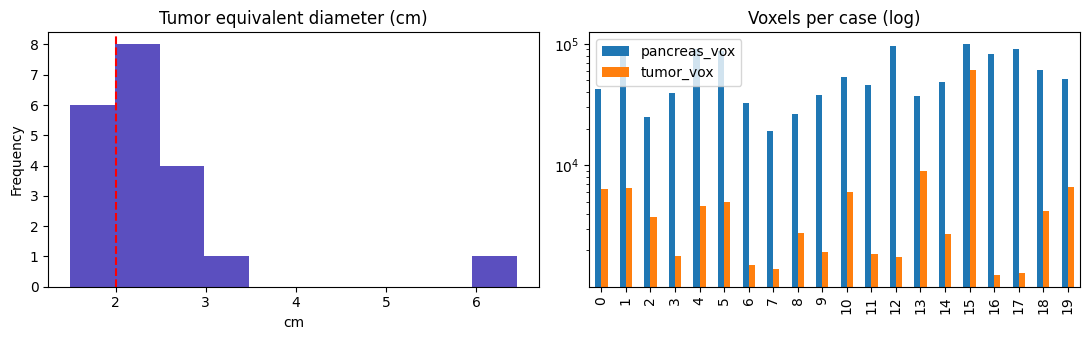

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
stats['eq_diam_cm'].plot.hist(bins=10, ax=ax[0], color='#5b4fbf'); ax[0].axvline(2.0, color='r', ls='--')
ax[0].set_title('Tumor equivalent diameter (cm)'); ax[0].set_xlabel('cm')
stats[['pancreas_vox','tumor_vox']].plot.bar(ax=ax[1], logy=True); ax[1].set_title('Voxels per case (log)')
plt.tight_layout(); plt.savefig(f'{RESULTS}/fig_raw_stats.png', dpi=150); plt.show()
sync()

## 4. Preprocessing pipeline (Stage 6.1, as specified in the report)
| Report step | Implementation |
|---|---|
| Uniform voxel spacing | `Spacingd(1.5, 1.5, 2.0 mm)` |
| Consistent orientation | `Orientationd(RAS)` |
| HU clip to pancreatic soft-tissue window | `ScaleIntensityRanged(-100 … 240 HU → 0 … 1)` |
| Intensity normalisation | same transform (min-max to [0,1]) |
| Augmentation (train only) | random flip, 90° rotation, elastic deformation |

In [8]:
SPACING = (1.5, 1.5, 2.0)
HU_MIN, HU_MAX = -100, 240

base = [
    LoadImaged(keys=['image','label']),
    EnsureChannelFirstd(keys=['image','label']),
    Orientationd(keys=['image','label'], axcodes='RAS'),
    Spacingd(keys=['image','label'], pixdim=SPACING, mode=('bilinear','nearest')),
    ScaleIntensityRanged(keys=['image'], a_min=HU_MIN, a_max=HU_MAX, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=['image','label'], source_key='image'),
    EnsureTyped(keys=['image','label']),
]
augment = [
    RandFlipd(keys=['image','label'], prob=0.5, spatial_axis=0),
    RandRotate90d(keys=['image','label'], prob=0.5, max_k=3, spatial_axes=(0,1)),
    Rand3DElasticd(keys=['image','label'], prob=1.0, sigma_range=(5,8), magnitude_range=(50,120),
                   mode=('bilinear','nearest'), padding_mode='zeros'),
]
val_tf   = Compose(base)
train_tf = Compose(base + augment)
print('val transforms  :', len(val_tf.transforms))
print('train transforms:', len(train_tf.transforms), '(incl. augmentation)')

val transforms  : 7
train transforms: 10 (incl. augmentation)


/usr/local/lib/python3.13/dist-packages/monai/utils/deprecate_utils.py:320: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


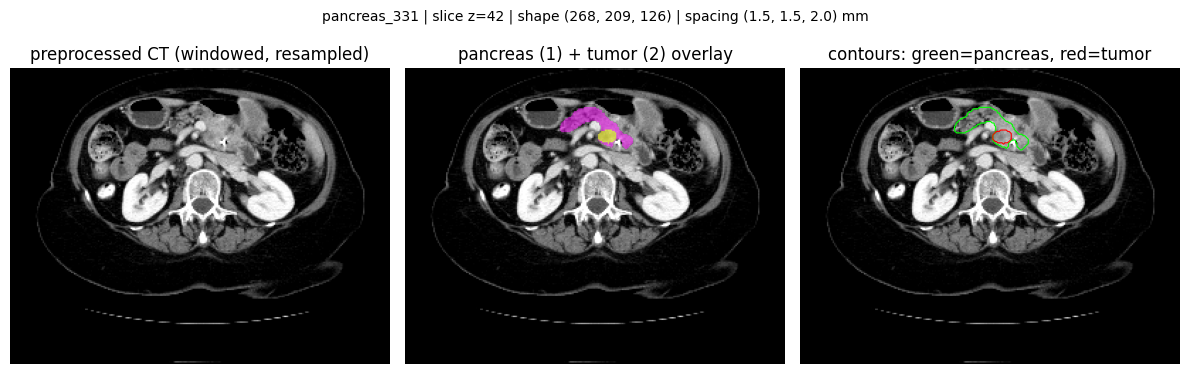

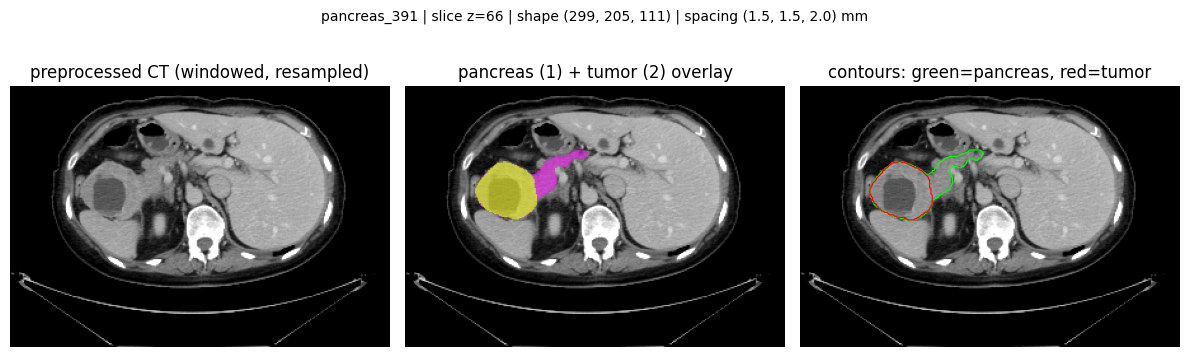

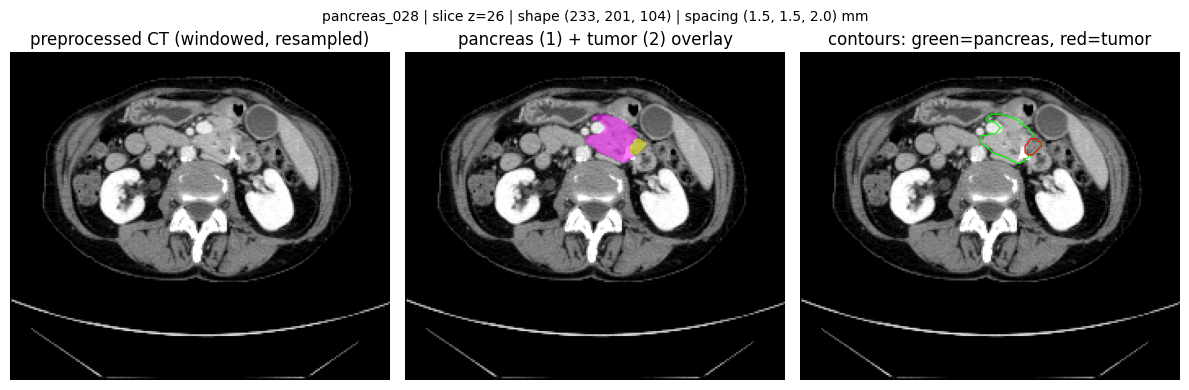

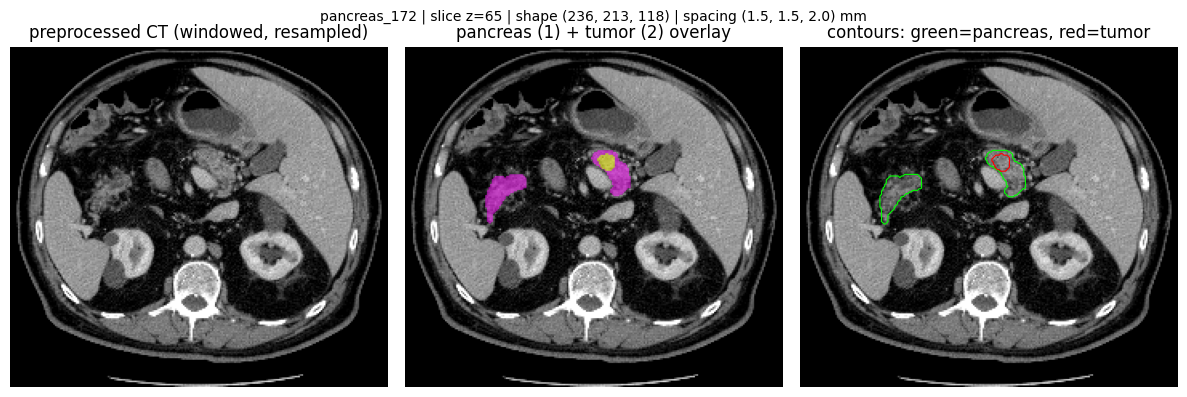

In [9]:
def best_axial(label):  # slice index with the largest tumor area, else largest pancreas area
    L = np.asarray(label)[0]
    area = (L == 2).sum(axis=(0,1))
    if area.max() == 0: area = (L >= 1).sum(axis=(0,1))
    return int(area.argmax())

def show_case(d, title, fname=None):
    img = np.asarray(d['image'])[0]; lab = np.asarray(d['label'])[0]
    z = best_axial(d['label'])
    im, lb = np.rot90(img[:,:,z]), np.rot90(lab[:,:,z])
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(im, cmap='gray'); ax[0].set_title('preprocessed CT (windowed, resampled)')
    ax[1].imshow(im, cmap='gray'); ax[1].imshow(np.ma.masked_where(lb==0, lb), cmap='spring', alpha=0.5); ax[1].set_title('pancreas (1) + tumor (2) overlay')
    ax[2].imshow(im, cmap='gray'); ax[2].contour(lb>=1, colors='lime', linewidths=0.8); ax[2].contour(lb==2, colors='red', linewidths=0.8); ax[2].set_title('contours: green=pancreas, red=tumor')
    for a in ax: a.axis('off')
    fig.suptitle(f'{title} | slice z={z} | shape {img.shape} | spacing {SPACING} mm', fontsize=10)
    plt.tight_layout()
    if fname: plt.savefig(fname, dpi=150)
    plt.show()

for f in val_files:
    d = val_tf(dict(f))
    name = os.path.basename(f['image']).replace('.nii.gz','')
    show_case(d, name, f'{RESULTS}/overlay_{name}.png')
sync()

### Augmentation check (train transforms only)

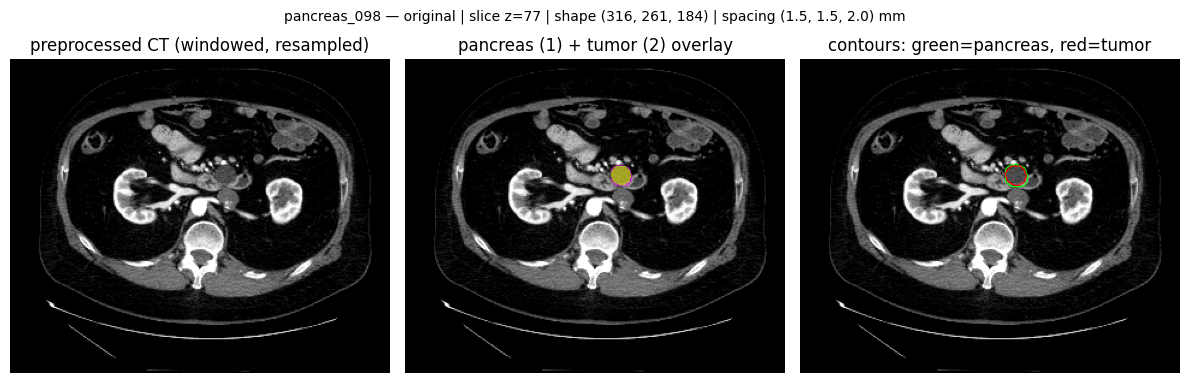

In [ ]:
f = train_files[0]; name = os.path.basename(f['image']).replace('.nii.gz','')
show_case(val_tf(dict(f)), f'{name} — original')
show_case(train_tf(dict(f)), f'{name} — augmented (flip / rot90 / elastic)', f'{RESULTS}/augment_{name}.png')
sync()

## 5. Pretrained baseline for ROI segmentation (Stage 6.2)
MONAI model-zoo bundle **`pancreas_ct_dints_segmentation`** — a 3-class (background / pancreas / tumor) 3D model trained on MSD Task07, reported mean Dice ≈ 0.62. We run it on our 4 held-out validation cases and score it.
This establishes the "existing system" baseline the Attention U-Net (Review 2) must beat.

In [ ]:
BUNDLE_DIR = '/content/bundles'
!python -m monai.bundle download --name pancreas_ct_dints_segmentation --bundle_dir {BUNDLE_DIR}
BUNDLE = f'{BUNDLE_DIR}/pancreas_ct_dints_segmentation'
print(os.listdir(BUNDLE)); print(os.listdir(f'{BUNDLE}/models'))

In [ ]:
# datalist in the format the bundle expects ('testing' key, paths relative to dataset_dir)
datalist = {'testing': [{'image': os.path.relpath(f['image'], TASK_DIR)} for f in val_files]}
DL_PATH = f'{BUNDLE}/configs/datalist_review1.json'
json.dump(datalist, open(DL_PATH, 'w'), indent=1)
PRED_DIR = '/content/baseline_pred'
print(json.dumps(datalist, indent=1))

In [ ]:
%%time
# torch >= 2.6 defaults torch.load(weights_only=True), which breaks the bundle's
# architecture checkpoint load - hence the explicit --arch_ckpt override.
# If this OOMs on a T4, append:  --inferer#sw_batch_size 1
!cd {BUNDLE} && python -m monai.bundle run \
    --config_file configs/inference.yaml \
    --bundle_root {BUNDLE} \
    --dataset_dir {TASK_DIR} \
    --data_list_file_path {DL_PATH} \
    --output_dir {PRED_DIR} \
    --arch_ckpt "$torch.load(@arch_ckpt_path, map_location=torch.device('cuda'), weights_only=False)"

In [ ]:
def dice(a, b):
    a, b = a.astype(bool), b.astype(bool)
    s = a.sum() + b.sum()
    return 1.0 if s == 0 else 2.0 * (a & b).sum() / s

rows = []
for f in val_files:
    name = os.path.basename(f['image']).replace('.nii.gz','')
    pred_path = glob.glob(f'{PRED_DIR}/{name}/*.nii.gz')[0]
    P = np.asarray(nib.load(pred_path).dataobj).squeeze()
    G = np.asarray(nib.load(f['label']).dataobj).squeeze()
    assert P.shape == G.shape, (P.shape, G.shape)
    rows.append(dict(case=name, dice_pancreas=round(dice(P>=1, G>=1),3), dice_tumor=round(dice(P==2, G==2),3),
                     gt_tumor_vox=int((G==2).sum()), pred_tumor_vox=int((P==2).sum())))
base_res = pd.DataFrame(rows)
base_res.loc['mean'] = base_res[['dice_pancreas','dice_tumor']].mean().round(3)
base_res.to_csv(f'{RESULTS}/baseline_dints_dice.csv')
base_res
sync()

In [ ]:
for f in val_files:
    name = os.path.basename(f['image']).replace('.nii.gz','')
    I = np.asarray(nib.load(f['image']).dataobj); G = np.asarray(nib.load(f['label']).dataobj).squeeze()
    P = np.asarray(nib.load(glob.glob(f'{PRED_DIR}/{name}/*.nii.gz')[0]).dataobj).squeeze()
    area = (G==2).sum(axis=(0,1));  area = area if area.max()>0 else (G>=1).sum(axis=(0,1)); z = int(area.argmax())
    im = np.clip(np.rot90(I[:,:,z]), HU_MIN, HU_MAX)
    fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
    for a, M, t in zip(ax, [G, P], ['ground truth', 'pretrained DiNTS prediction']):
        m = np.rot90(M[:,:,z]); a.imshow(im, cmap='gray')
        a.contour(m>=1, colors='lime', linewidths=0.9); a.contour(m==2, colors='red', linewidths=0.9)
        a.set_title(t); a.axis('off')
    r = base_res.loc[base_res.case==name].iloc[0]
    fig.suptitle(f'{name} | z={z} | Dice pancreas={r.dice_pancreas} tumor={r.dice_tumor}', fontsize=10)
    plt.tight_layout(); plt.savefig(f'{RESULTS}/baseline_{name}.png', dpi=150); plt.show()
sync()

## 6. Deliverables produced by this notebook

In [ ]:
sync()
print('files in results/review1:')
for p in sorted(os.listdir(RESULTS)):
    size = os.path.getsize(os.path.join(RESULTS, p)) / 1024
    print(f'  {p:<44}{size:>8.0f} KB')

# One zip to drop straight into the repo's results/review1/ folder.
zip_path = shutil.make_archive('/content/review1_results', 'zip', RESULTS)
print(f'\nzip: {zip_path} ({os.path.getsize(zip_path)/1e6:.1f} MB)')
if DRIVE_RESULTS:
    shutil.copy(zip_path, os.path.dirname(DRIVE_RESULTS) + '/review1_results.zip')
    print('copied to Drive: MyDrive/pancreas_project/results/review1_results.zip')

try:
    from google.colab import files
    files.download(zip_path)      # unzip into the repo at results/review1/, then commit
except Exception as e:
    print('auto-download unavailable (%s); grab it from Drive instead' % type(e).__name__)

**Screenshots for the Review 1 deck (item 9 of the circular):**
1. `nvidia-smi` + MONAI config output (environment)
2. Dataset summary printout + `raw_stats_subset.csv` table and `fig_raw_stats.png`
3. Two or three `overlay_*.png` (Stage 6.1 output)
4. `augment_*.png`
5. Bundle run log + `baseline_dints_dice.csv`
6. Two `baseline_*.png` GT-vs-prediction figures (Stage 6.2 baseline)

**Honest statement for the panel:** pipeline validated on MSD Pancreas (20-case subset); the pretrained baseline gives Dice X / Y on our held-out cases; Attention U-Net training and PanTS external validation are the Review 2 targets.

**Next (Review 2):** `02_segmentation_attention_unet.ipynb` — train `monai.networks.nets.AttentionUnet` with `train_tf`, compare to this baseline.